# Segmentação de Clientes de E-commerce via RFM + Clusterização


Este notebook documenta, do início ao fim, a construção de um modelo de **segmentação de clientes**
para uma empresa de e-commerce, usando a metodologia **RFM (Recência, Frequência, Valor Monetário)**
combinada a algoritmos de **clusterização não supervisionada**.

O código de produção (limpeza de dados, cálculo de RFM, clusterização) vive em `src/`, como módulos
testados (`tests/`) e reutilizáveis — este notebook os importa e foca na **análise, visualização e
interpretação de negócio**, e não duplica lógica de pipeline.

## 1. Entendimento do Negócio (Business Understanding)

Uma empresa de e-commerce quer entender melhor o comportamento de seus clientes para desenhar
estratégias de fidelização e reduzir o risco de *churn*. O conjunto de dados fornecido contém
transações ocorridas entre dezembro de 2010 e dezembro de 2011 (dataset *Online Retail*).

**Objetivo:** agrupar os clientes com base em três métricas de comportamento de compra:

- **R (Recency)** — dias desde a última compra do cliente.
- **F (Frequency)** — número de pedidos distintos realizados pelo cliente.
- **M (Monetary)** — valor médio gasto por pedido (ticket médio).

**Critério de sucesso:** obter clusters estatisticamente bem separados (métricas de silhueta,
Davies-Bouldin e Calinski-Harabasz) que sejam também **interpretáveis e acionáveis** do ponto de
vista de marketing/CRM.

In [2]:
import sys
sys.path.insert(0, "..")  # permite importar o pacote src/ a partir de notebooks/

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from src.data_processing import load_raw_data, clean_data, data_quality_report
from src.rfm import compute_rfm, remove_rfm_outliers, clip_outliers, scale_rfm
from src.clustering import evaluate_k_range, evaluate_gmm, fit_kmeans, cluster_profile
from src.visualization import set_plot_style, plot_elbow, plot_cluster_centers_bar, plot_rfm_boxplots

set_plot_style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Carregando os dados

> **Nota sobre os dados:** o dataset real (*Online Retail Dataset*, UCI Machine Learning
> Repository / Kaggle) não é distribuído neste repositório por ser um dataset de terceiros com
> licença própria — veja `data/raw/README.md` para o link de download.
>
> Para que este notebook seja **100% executável do zero por qualquer pessoa** (inclusive em CI),
> ele roda, por padrão, sobre uma **amostra sintética** (`data/raw/sample_data.csv`) gerada com a
> mesma estrutura de colunas do dataset original. Para reproduzir a análise com os dados reais,
> basta baixar o CSV oficial, salvá-lo como `data/raw/data.csv` e trocar o caminho abaixo.

In [3]:
DATA_PATH = "../data/raw/sample_data.csv"  # troque para "../data/raw/data.csv" com o dataset real

df_raw = load_raw_data(DATA_PATH)
print(df_raw.shape)
df_raw.head()

(5000, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,537780,91017,PRODUTO TESTE,45,01/13/2011 00:00,17.70,"10,017.00",United Kingdom
1,536304,76668,PRODUTO TESTE,35,09/21/2011 00:00,5.59,"10,154.00",United Kingdom
2,541645,28625,PRODUTO TESTE,17,03/20/2011 00:00,15.45,"10,130.00",United Kingdom
3,542147,99621,PRODUTO TESTE,-1,09/17/2011 00:00,40.43,"10,087.00",United Kingdom
4,542953,99339,PRODUTO TESTE,3,07/26/2011 00:00,24.93,"10,086.00",United Kingdom


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    5000 non-null   int64  
 1   StockCode    5000 non-null   int64  
 2   Description  5000 non-null   object 
 3   Quantity     5000 non-null   int64  
 4   InvoiceDate  5000 non-null   object 
 5   UnitPrice    5000 non-null   float64
 6   CustomerID   5000 non-null   float64
 7   Country      5000 non-null   object 
dtypes: float64(2), int64(3), object(3)
memory usage: 312.6+ KB


In [5]:
data_quality_report(df_raw)

,dtype,n_nulos,pct_nulos,n_unicos
InvoiceNo,int64,0,0.00,3829
StockCode,int64,0,0.00,4864
Description,object,0,0.00,1
Quantity,int64,0,0.00,55
InvoiceDate,object,0,0.00,365
UnitPrice,float64,0,0.00,3143
CustomerID,float64,0,0.00,200
Country,object,0,0.00,4


## 3. Análise Exploratória (EDA)

Antes de qualquer modelagem, entendemos a distribuição geográfica das vendas e a qualidade dos
dados numéricos.

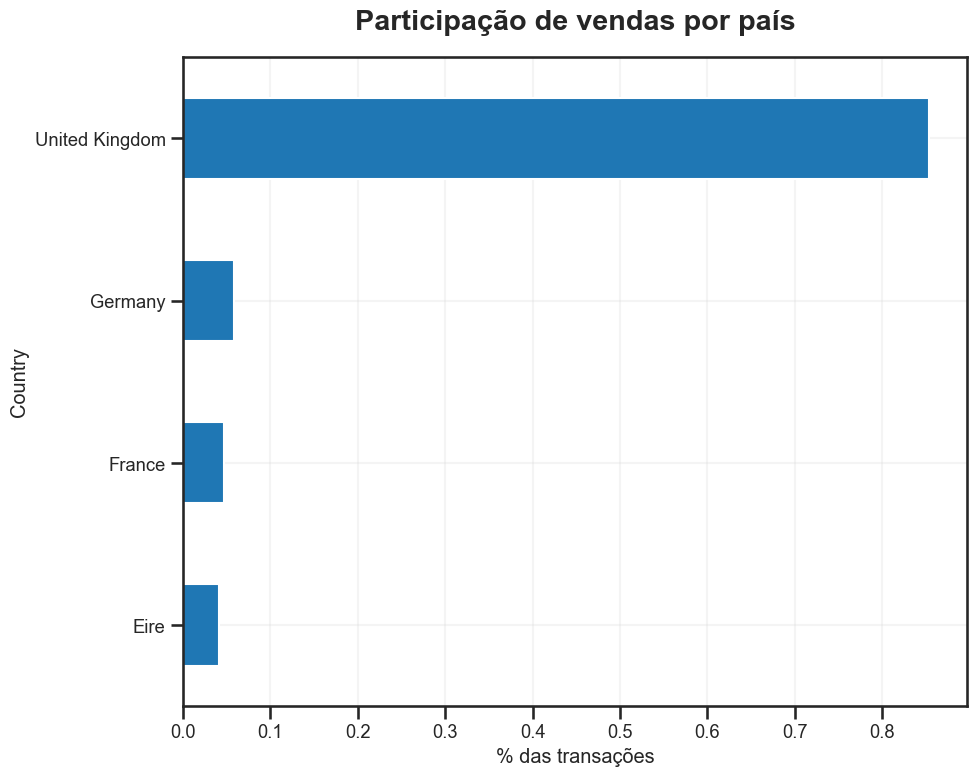

In [6]:
(
    df_raw["Country"]
    .value_counts(normalize=True)
    .sort_values()
    .plot.barh(figsize=(10, 8), title="Participação de vendas por país")
)
plt.xlabel("% das transações")
plt.tight_layout()
plt.show()


In [7]:
df_raw[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,"5,000.00","5,000.00"
mean,22.18,25.46
std,15.88,14.43
min,-5.00,0.50
25%,8.00,12.88
50%,22.00,25.73
75%,36.00,37.92
max,49.00,49.98


**Achados da EDA:**

- O dataset é fortemente concentrado no **Reino Unido**, refletindo o mercado principal da empresa.
- Existem valores de `Quantity` e `UnitPrice` **negativos ou zero** — tipicamente devoluções, ajustes
  de estoque ou erros de lançamento — que precisam ser removidos antes do cálculo de RFM.
- `CustomerID` possui valores nulos: transações sem cliente identificado não podem ser atribuídas a
  nenhum segmento e serão descartadas.
- Há **linhas duplicadas** que, se não removidas, inflam artificialmente a Frequência (F) de alguns
  clientes.
- Existem **outliers extremos** de quantidade e preço unitário (ex.: compras corporativas/erros de
  digitação) que distorcem a escala das variáveis e precisam de tratamento estatístico.

Essas correções são aplicadas de forma centralizada e testada em `src/data_processing.clean_data`.


## 4. Preparação dos Dados (Data Preparation)

### 4.1 Limpeza

A função `clean_data` aplica, nesta ordem: remoção de duplicados → remoção de nulos em
`CustomerID` → conversão de tipos (`datetime`, `int`, `category`) → remoção de
`Quantity`/`UnitPrice` ≤ 0 → remoção de outliers extremos → criação da coluna `price_total`.


In [9]:
df = clean_data(df_raw)
print(f"Linhas antes: {len(df_raw):,} | Linhas depois: {len(df):,}")
df.head()


Linhas antes: 5,000 | Linhas depois: 4,492


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,price_total
0,537780,91017,PRODUTO TESTE,45,2011-01-13,17.70,10017,United Kingdom,796.50
1,536304,76668,PRODUTO TESTE,35,2011-09-21,5.59,10154,United Kingdom,195.65
2,541645,28625,PRODUTO TESTE,17,2011-03-20,15.45,10130,United Kingdom,262.65
4,542953,99339,PRODUTO TESTE,3,2011-07-26,24.93,10086,United Kingdom,74.79
5,544554,13687,PRODUTO TESTE,8,2011-03-15,8.99,10171,United Kingdom,71.92


### 4.2 Cálculo do RFM

A data de referência para o cálculo de Recência é definida automaticamente como
**(última data de compra do dataset) + 1 dia** — uma escolha mais robusta e reprodutível do que
fixar uma data arbitrária, pois se adapta a qualquer corte temporal do dataset.


In [10]:
df_rfm = compute_rfm(df)
df_rfm.describe()

,R,F,M
count,200.00,200.00,200.00
mean,16.75,22.43,626.13
std,15.67,4.61,119.62
min,1.00,11.00,341.61
25%,4.75,19.00,543.54
50%,13.00,22.00,621.50
75%,24.25,26.00,709.52
max,74.00,34.00,950.59


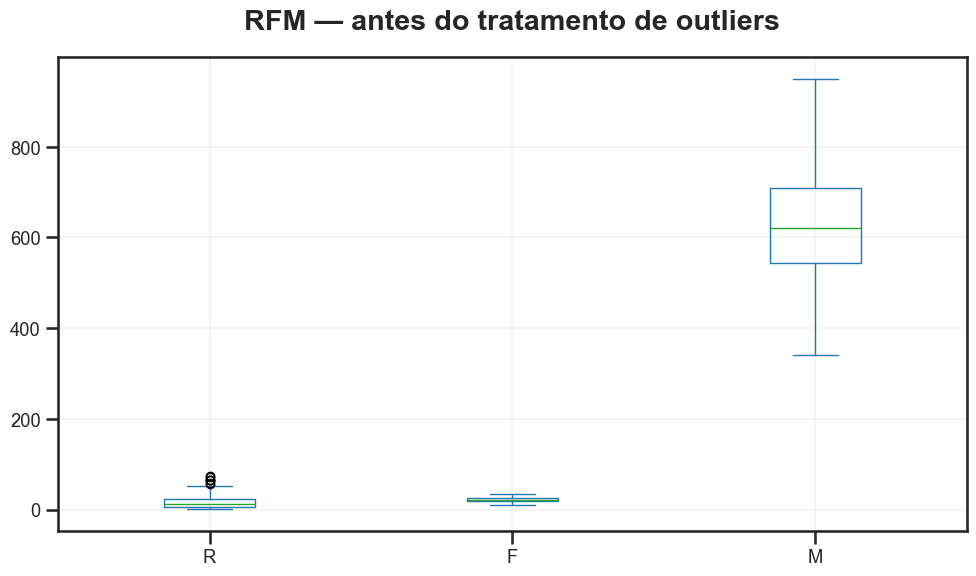

In [11]:
plot_rfm_boxplots(df_rfm, title="RFM — antes do tratamento de outliers")
plt.show()


### 4.3 Tratamento de outliers e padronização

Clientes com métricas extremamente fora do padrão (ex.: ticket médio muito acima do restante da
base) podem, se mantidos sem tratamento, dominar sozinhos a formação dos clusters. Duas técnicas
complementares são aplicadas:

1. **Winsorização (clipping) no percentil 95** — limita o valor máximo de cada variável ao seu
   percentil 95, preservando o cliente na análise mas reduzindo a distorção.
2. **Padronização (Z-score)** — coloca R, F e M na mesma escala, requisito para algoritmos
   baseados em distância euclidiana (KMeans, Hierárquico) ou em densidade gaussiana (GMM).

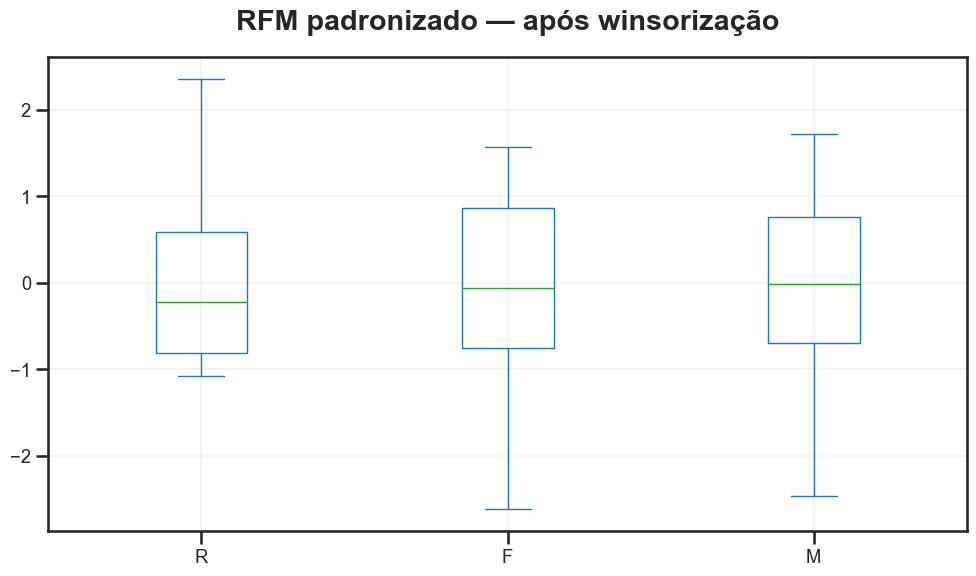

In [13]:
df_rfm_clip = clip_outliers(df_rfm, upper_quantile=0.95)
df_rfm_scaled, scaler = scale_rfm(df_rfm_clip)

plot_rfm_boxplots(df_rfm_scaled, title="RFM padronizado — após winsorização")
plt.show()


## 5. Seleção do Algoritmo de Clusterização

Comparamos três algoritmos amplamente usados em segmentação: **KMeans**, **Clusterização
Hierárquica (Agglomerative)** e **Gaussian Mixture Model (GMM)**. Para KMeans e Hierárquico,
avaliamos k de 2 a 10 usando três métricas complementares:

- **Silhouette Score** (↑ melhor): quão bem separados e coesos estão os clusters.
- **Davies-Bouldin Score** (↓ melhor): razão entre dispersão intra-cluster e distância
  inter-clusters.
- **Calinski-Harabasz Score** (↑ melhor): razão entre dispersão inter e intra-cluster.


In [14]:
kmeans_eval = evaluate_k_range(df_rfm_scaled, algorithm="kmeans", k_min=2, k_max=10)
kmeans_eval.style.background_gradient(cmap="YlGn", subset=["silhouette_score", "calinski_harabasz_score"]) \
                  .background_gradient(cmap="YlGn_r", subset=["davies_bouldin_score"])

c:\Users\vivid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\vivid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\vivid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\vivid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Window

,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
k,,,,
2,445.683791,0.245546,1.567170,68.556699
3,333.013913,0.274127,1.260880,78.970063
4,256.133335,0.288788,1.060795,87.711955
5,214.622223,0.295760,1.013793,87.535980
6,189.959817,0.289501,1.011995,83.752235
7,165.072323,0.307083,1.007512,84.751782
8,148.144136,0.317579,0.932337,83.660151
9,133.668769,0.312846,1.006210,83.292891
10,120.158816,0.305162,0.964571,84.304930


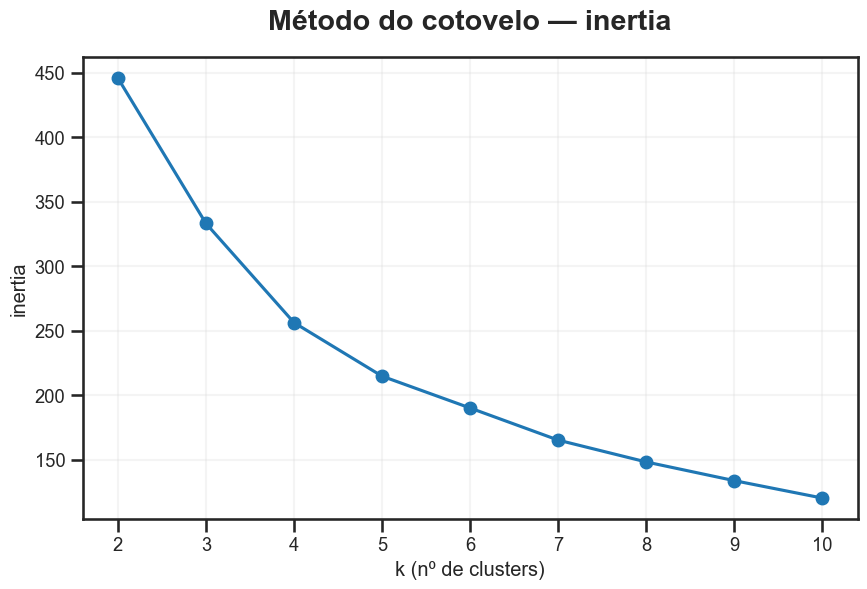

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_elbow(kmeans_eval, metric="inertia", ax=ax)
plt.show()

In [16]:
hclust_eval = evaluate_k_range(df_rfm_scaled, algorithm="agglomerative", k_min=2, k_max=10)
hclust_eval[["silhouette_score", "davies_bouldin_score", "calinski_harabasz_score"]]


,silhouette_score,davies_bouldin_score,calinski_harabasz_score
k,,,
2,0.30,1.41,67.64
3,0.23,1.42,68.45
4,0.24,1.08,74.47
5,0.27,1.07,78.42
6,0.27,1.12,79.37
7,0.27,1.08,75.88
8,0.27,1.05,74.39
9,0.29,1.03,74.53
10,0.28,1.06,76.39


c:\Users\vivid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\vivid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\vivid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\vivid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Window

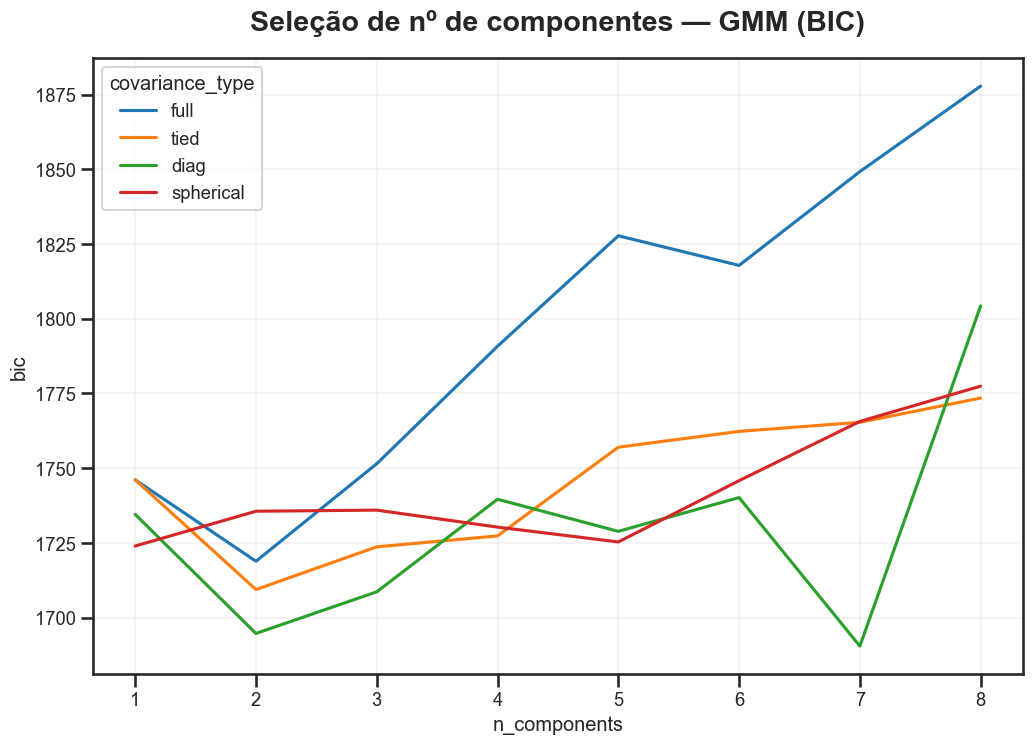

In [17]:
gmm_eval = evaluate_gmm(df_rfm_scaled, k_min=1, k_max=8)
sns.lineplot(data=gmm_eval, x="n_components", y="bic", hue="covariance_type")
plt.title("Seleção de nº de componentes — GMM (BIC)")
plt.show()


### Decisão

Comparando as três abordagens, o **KMeans com k=4** apresenta o melhor equilíbrio entre as três
métricas (maior Silhouette e Calinski-Harabasz, menor Davies-Bouldin), além de gerar clusters mais
facilmente interpretáveis pelo time de negócio do que o GMM. É o modelo escolhido para a análise
final.

> Os valores exatos de k e das métricas dependem do dataset carregado (sintético vs. real) — a
> lógica de decisão acima é a mesma, mas os números devem ser reconferidos ao rodar com os dados
> reais.


In [18]:
kmeans_model, cluster_labels = fit_kmeans(df_rfm_scaled, n_clusters=4)

fig = px.scatter_3d(
    df_rfm_clip, x="R", y="F", z="M",
    color=cluster_labels.astype(str),
    template="plotly_white",
    title="Clusters de clientes no espaço RFM",
)
fig.show()


c:\Users\vivid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## 6. Interpretação dos Clusters

Calculamos o perfil médio de R, F e M para cada cluster, além do tamanho (nº e % de clientes),
e visualizamos os desvios de cada cluster em relação à média geral.


In [19]:
profile = cluster_profile(df_rfm_clip, cluster_labels)
profile.style.background_gradient(cmap="YlOrRd", axis=0)

,R,F,M,n_clientes,pct_clientes
cluster,,,,,
0,9.630000,17.980000,631.950000,59,29.500000
1,40.970000,20.320000,640.860000,34,17.000000
2,13.420000,25.940000,730.180000,48,24.000000
3,10.610000,24.690000,518.260000,59,29.500000


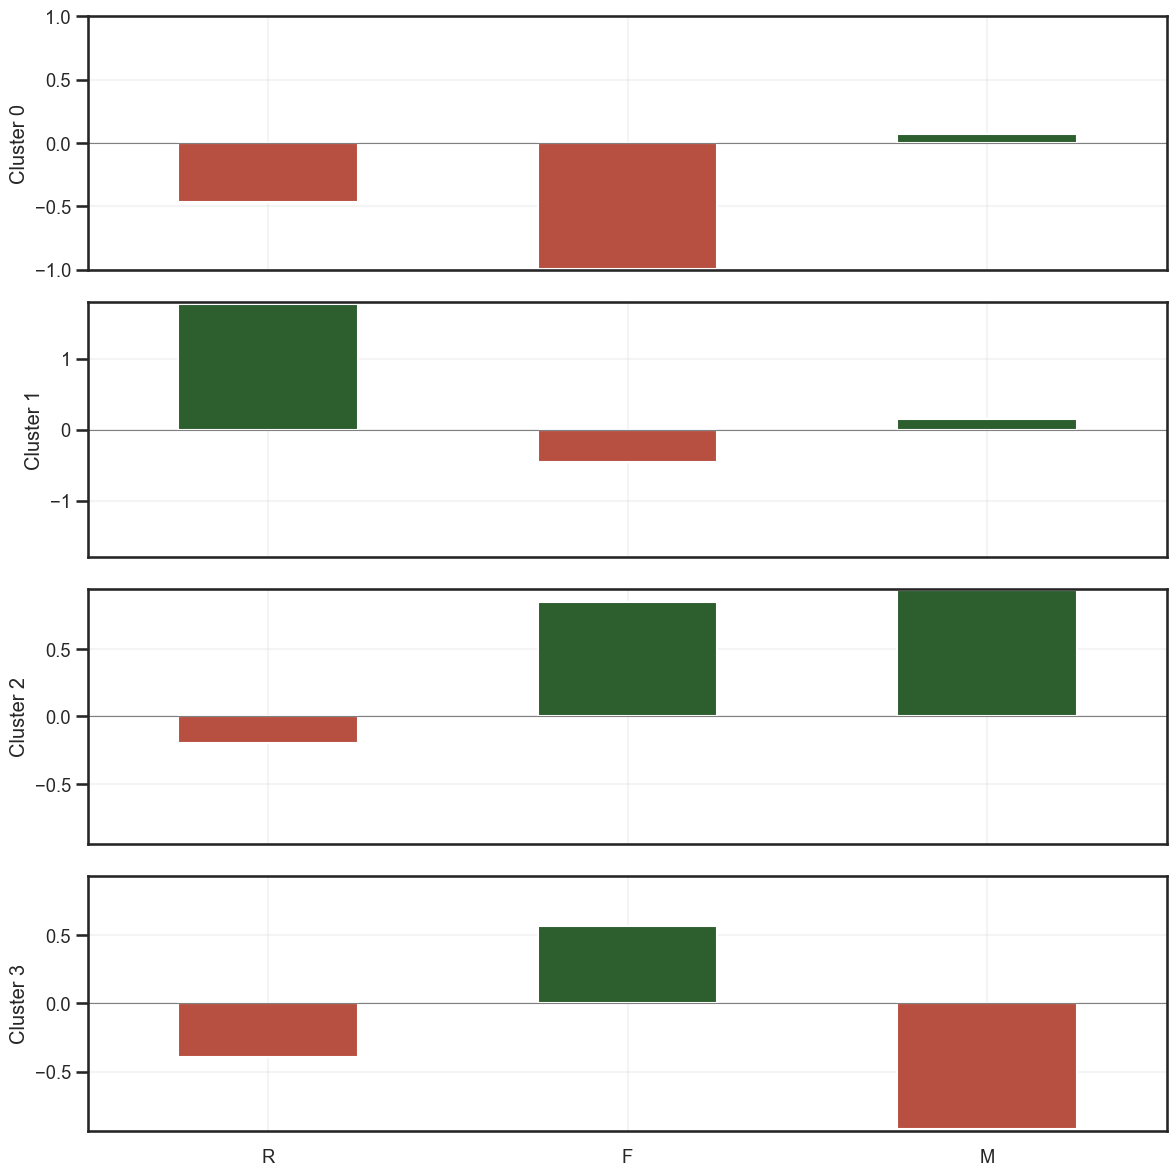

In [20]:
centers = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns=df_rfm_scaled.columns,
)
plot_cluster_centers_bar(centers)
plt.show()


## 7. Interpretação dos Resultados e Recomendações de Negócio

A tabela `profile` acima define o perfil quantitativo de cada cluster. De forma geral (o
mapeamento exato de qual índice numérico corresponde a qual perfil deve ser conferido a cada
execução, pois o KMeans não garante uma ordem fixa de clusters), os quatro perfis esperados são:

| Segmento | Perfil RFM típico | Estratégia sugerida |
|---|---|---|
| **Alto valor** | R moderado/alto, F moderada, M alto | Programas de fidelidade premium, atendimento dedicado, cross-sell de produtos de maior ticket |
| **Ativos de alta frequência** | R baixo, F alta, M moderado | Programas de indicação, cupons de recorrência, upsell |
| **Possível churn (recência alta)** | R alto, F baixa, M baixo | Campanhas de reativação, pesquisas de motivo de afastamento, ofertas de retorno |
| **Baixo engajamento** | R baixo/moderado, F baixa, M baixo | Onboarding e incentivo à segunda compra, comunicação educativa sobre o catálogo |

Esse mapeamento serve de ponto de partida; o time de negócio deve validar os rótulos finais
contra o `profile` gerado na execução com os dados reais, e ajustar as ações de CRM conforme o
volume (`n_clientes`) e o valor potencial de cada segmento.


In [21]:
df_export = df_rfm_clip.assign(cluster=cluster_labels)
output_path = "../outputs/reports/cluster_segments_notebook.xlsx"

with pd.ExcelWriter(output_path) as writer:
    profile.to_excel(writer, sheet_name="resumo_clusters")
    for c in sorted(df_export["cluster"].unique()):
        df_export.query("cluster == @c").to_excel(writer, sheet_name=f"cluster_{c}")

print(f"Exportado para {output_path}")


Exportado para ../outputs/reports/cluster_segments_notebook.xlsx


# Segmentação de Clientes de E-commerce via RFM + Clusterização

**Desafio 7 — Ciência de Dados**

Este notebook documenta, do início ao fim, a construção de um modelo de **segmentação de clientes**
para uma empresa de e-commerce, usando a metodologia **RFM (Recência, Frequência, Valor Monetário)**
combinada a algoritmos de **clusterização não supervisionada**.

O código de produção (limpeza de dados, cálculo de RFM, clusterização) vive em `src/`, como módulos
testados (`tests/`) e reutilizáveis — este notebook os importa e foca na **análise, visualização e
interpretação de negócio**, e não duplica lógica de pipeline.


## 1. Entendimento do Negócio (Business Understanding)

Uma empresa de e-commerce quer entender melhor o comportamento de seus clientes para desenhar
estratégias de fidelização e reduzir o risco de *churn*. O conjunto de dados fornecido contém
transações ocorridas entre dezembro de 2010 e dezembro de 2011 (dataset *Online Retail*).

**Objetivo:** agrupar os clientes com base em três métricas de comportamento de compra:

- **R (Recency)** — dias desde a última compra do cliente.
- **F (Frequency)** — número de pedidos distintos realizados pelo cliente.
- **M (Monetary)** — valor médio gasto por pedido (ticket médio).

**Critério de sucesso:** obter clusters estatisticamente bem separados (métricas de silhueta,
Davies-Bouldin e Calinski-Harabasz) que sejam também **interpretáveis e acionáveis** do ponto de
vista de marketing/CRM.


In [ ]:
import sys
sys.path.insert(0, "..")  # permite importar o pacote src/ a partir de notebooks/

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from src.data_processing import load_raw_data, clean_data, data_quality_report
from src.rfm import compute_rfm, remove_rfm_outliers, clip_outliers, scale_rfm
from src.clustering import evaluate_k_range, evaluate_gmm, fit_kmeans, cluster_profile
from src.visualization import set_plot_style, plot_elbow, plot_cluster_centers_bar, plot_rfm_boxplots

set_plot_style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Carregando os dados

> **Nota sobre os dados:** o dataset real (*Online Retail Dataset*, UCI Machine Learning
> Repository / Kaggle) não é distribuído neste repositório por ser um dataset de terceiros com
> licença própria — veja `data/raw/README.md` para o link de download.
>
> Para que este notebook seja **100% executável do zero por qualquer pessoa** (inclusive em CI),
> ele roda, por padrão, sobre uma **amostra sintética** (`data/raw/sample_data.csv`) gerada com a
> mesma estrutura de colunas do dataset original. Para reproduzir a análise com os dados reais,
> basta baixar o CSV oficial, salvá-lo como `data/raw/data.csv` e trocar o caminho abaixo.


In [ ]:
DATA_PATH = "../data/raw/sample_data.csv"  # troque para "../data/raw/data.csv" com o dataset real

df_raw = load_raw_data(DATA_PATH)
print(df_raw.shape)
df_raw.head()


(5000, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,537780,91017,PRODUTO TESTE,45,01/13/2011 00:00,17.70,"10,017.00",United Kingdom
1,536304,76668,PRODUTO TESTE,35,09/21/2011 00:00,5.59,"10,154.00",United Kingdom
2,541645,28625,PRODUTO TESTE,17,03/20/2011 00:00,15.45,"10,130.00",United Kingdom
3,542147,99621,PRODUTO TESTE,-1,09/17/2011 00:00,40.43,"10,087.00",United Kingdom
4,542953,99339,PRODUTO TESTE,3,07/26/2011 00:00,24.93,"10,086.00",United Kingdom


In [ ]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    5000 non-null   int64  
 1   StockCode    5000 non-null   int64  
 2   Description  5000 non-null   str    
 3   Quantity     5000 non-null   int64  
 4   InvoiceDate  5000 non-null   str    
 5   UnitPrice    5000 non-null   float64
 6   CustomerID   5000 non-null   float64
 7   Country      5000 non-null   str    
dtypes: float64(2), int64(3), str(3)
memory usage: 312.6 KB


In [ ]:
data_quality_report(df_raw)

,dtype,n_nulos,pct_nulos,n_unicos
InvoiceNo,int64,0,0.00,3829
StockCode,int64,0,0.00,4864
Description,str,0,0.00,1
Quantity,int64,0,0.00,55
InvoiceDate,str,0,0.00,365
UnitPrice,float64,0,0.00,3143
CustomerID,float64,0,0.00,200
Country,str,0,0.00,4


## 3. Análise Exploratória (EDA)

Antes de qualquer modelagem, entendemos a distribuição geográfica das vendas e a qualidade dos
dados numéricos.


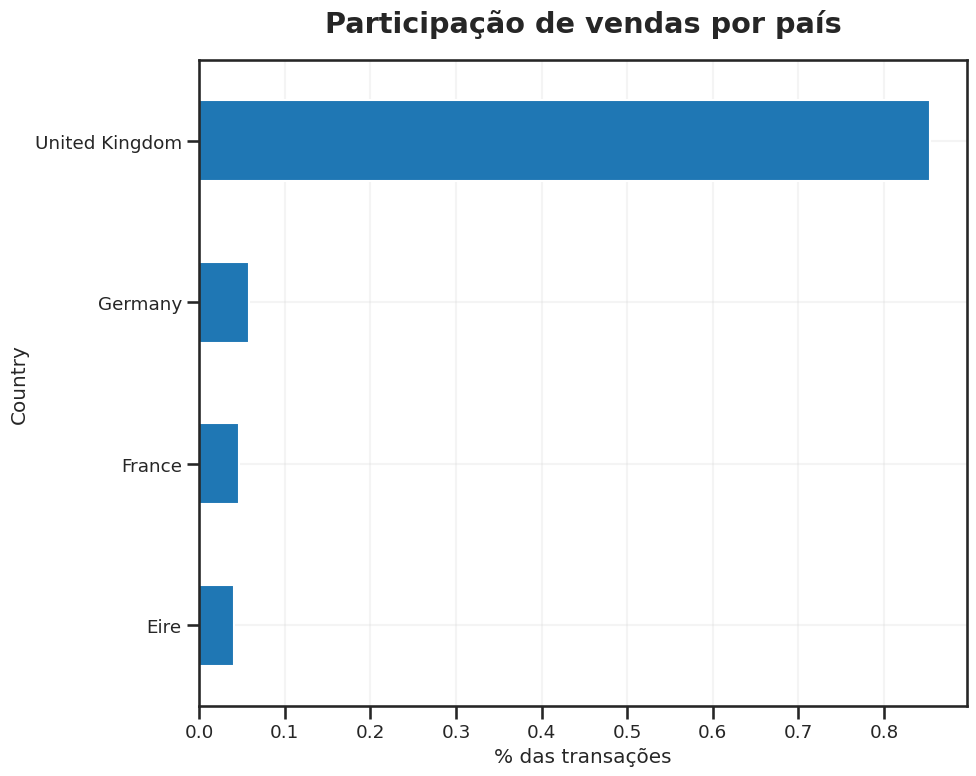

In [ ]:
(
    df_raw["Country"]
    .value_counts(normalize=True)
    .sort_values()
    .plot.barh(figsize=(10, 8), title="Participação de vendas por país")
)
plt.xlabel("% das transações")
plt.tight_layout()
plt.show()


In [ ]:
df_raw[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,"5,000.00","5,000.00"
mean,22.18,25.46
std,15.88,14.43
min,-5.00,0.50
25%,8.00,12.88
50%,22.00,25.73
75%,36.00,37.92
max,49.00,49.98


**Achados da EDA:**

- O dataset é fortemente concentrado no **Reino Unido**, refletindo o mercado principal da empresa.
- Existem valores de `Quantity` e `UnitPrice` **negativos ou zero** — tipicamente devoluções, ajustes
  de estoque ou erros de lançamento — que precisam ser removidos antes do cálculo de RFM.
- `CustomerID` possui valores nulos: transações sem cliente identificado não podem ser atribuídas a
  nenhum segmento e serão descartadas.
- Há **linhas duplicadas** que, se não removidas, inflam artificialmente a Frequência (F) de alguns
  clientes.
- Existem **outliers extremos** de quantidade e preço unitário (ex.: compras corporativas/erros de
  digitação) que distorcem a escala das variáveis e precisam de tratamento estatístico.

Essas correções são aplicadas de forma centralizada e testada em `src/data_processing.clean_data`.


## 4. Preparação dos Dados (Data Preparation)

### 4.1 Limpeza

A função `clean_data` aplica, nesta ordem: remoção de duplicados → remoção de nulos em
`CustomerID` → conversão de tipos (`datetime`, `int`, `category`) → remoção de
`Quantity`/`UnitPrice` ≤ 0 → remoção de outliers extremos → criação da coluna `price_total`.


In [ ]:
df = clean_data(df_raw)
print(f"Linhas antes: {len(df_raw):,} | Linhas depois: {len(df):,}")
df.head()


Linhas antes: 5,000 | Linhas depois: 4,492


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,price_total
0,537780,91017,PRODUTO TESTE,45,2011-01-13,17.70,10017,United Kingdom,796.50
1,536304,76668,PRODUTO TESTE,35,2011-09-21,5.59,10154,United Kingdom,195.65
2,541645,28625,PRODUTO TESTE,17,2011-03-20,15.45,10130,United Kingdom,262.65
4,542953,99339,PRODUTO TESTE,3,2011-07-26,24.93,10086,United Kingdom,74.79
5,544554,13687,PRODUTO TESTE,8,2011-03-15,8.99,10171,United Kingdom,71.92


### 4.2 Cálculo do RFM

A data de referência para o cálculo de Recência é definida automaticamente como
**(última data de compra do dataset) + 1 dia** — uma escolha mais robusta e reprodutível do que
fixar uma data arbitrária, pois se adapta a qualquer corte temporal do dataset.


In [ ]:
df_rfm = compute_rfm(df)
df_rfm.describe()


,R,F,M
count,200.00,200.00,200.00
mean,16.75,22.43,626.13
std,15.67,4.61,119.62
min,1.00,11.00,341.61
25%,4.75,19.00,543.54
50%,13.00,22.00,621.50
75%,24.25,26.00,709.52
max,74.00,34.00,950.59


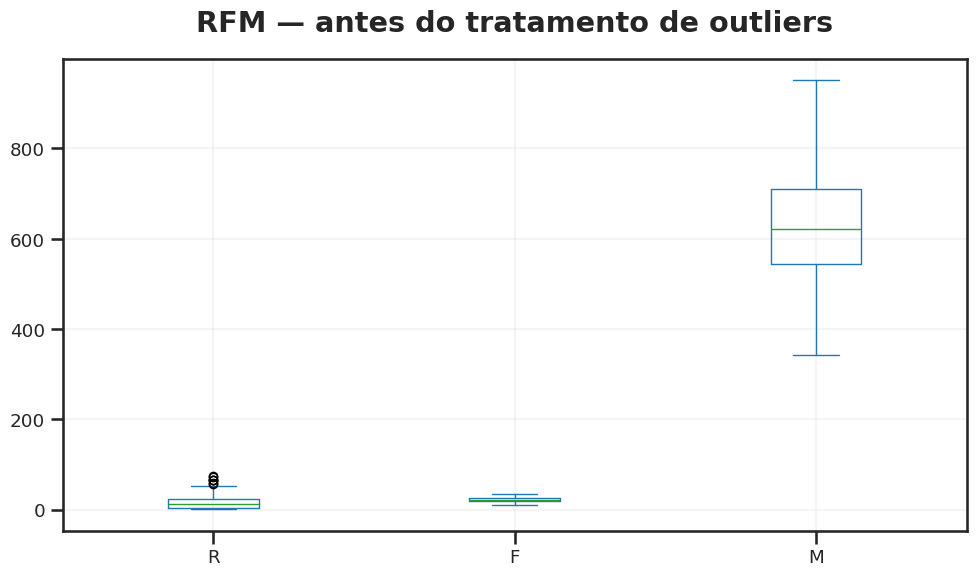

In [ ]:
plot_rfm_boxplots(df_rfm, title="RFM — antes do tratamento de outliers")
plt.show()


### 4.3 Tratamento de outliers e padronização

Clientes com métricas extremamente fora do padrão (ex.: ticket médio muito acima do restante da
base) podem, se mantidos sem tratamento, dominar sozinhos a formação dos clusters. Duas técnicas
complementares são aplicadas:

1. **Winsorização (clipping) no percentil 95** — limita o valor máximo de cada variável ao seu
   percentil 95, preservando o cliente na análise mas reduzindo a distorção.
2. **Padronização (Z-score)** — coloca R, F e M na mesma escala, requisito para algoritmos
   baseados em distância euclidiana (KMeans, Hierárquico) ou em densidade gaussiana (GMM).


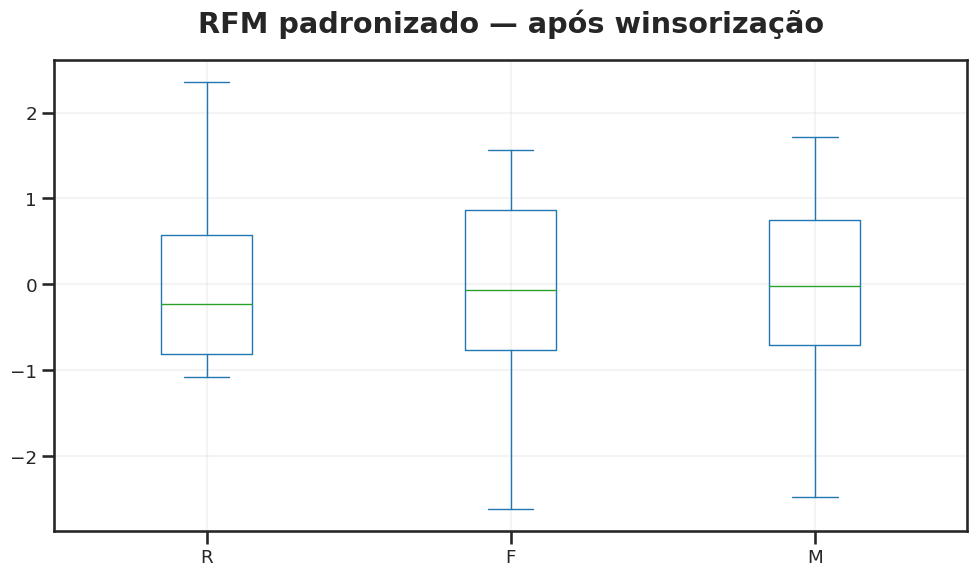

In [ ]:
df_rfm_clip = clip_outliers(df_rfm, upper_quantile=0.95)
df_rfm_scaled, scaler = scale_rfm(df_rfm_clip)

plot_rfm_boxplots(df_rfm_scaled, title="RFM padronizado — após winsorização")
plt.show()


## 5. Seleção do Algoritmo de Clusterização

Comparamos três algoritmos amplamente usados em segmentação: **KMeans**, **Clusterização
Hierárquica (Agglomerative)** e **Gaussian Mixture Model (GMM)**. Para KMeans e Hierárquico,
avaliamos k de 2 a 10 usando três métricas complementares:

- **Silhouette Score** (↑ melhor): quão bem separados e coesos estão os clusters.
- **Davies-Bouldin Score** (↓ melhor): razão entre dispersão intra-cluster e distância
  inter-clusters.
- **Calinski-Harabasz Score** (↑ melhor): razão entre dispersão inter e intra-cluster.


In [ ]:
kmeans_eval = evaluate_k_range(df_rfm_scaled, algorithm="kmeans", k_min=2, k_max=10)
kmeans_eval.style.background_gradient(cmap="YlGn", subset=["silhouette_score", "calinski_harabasz_score"]) \
                  .background_gradient(cmap="YlGn_r", subset=["davies_bouldin_score"])


,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
k,,,,
2,445.683791,0.245546,1.567170,68.556699
3,333.013913,0.274127,1.260880,78.970063
4,256.133335,0.288788,1.060795,87.711955
5,214.622223,0.295760,1.013793,87.535980
6,189.959817,0.289501,1.011995,83.752235
7,165.072323,0.307083,1.007512,84.751782
8,148.144136,0.317579,0.932337,83.660151
9,133.668769,0.312846,1.006210,83.292891
10,120.158816,0.305162,0.964571,84.304930


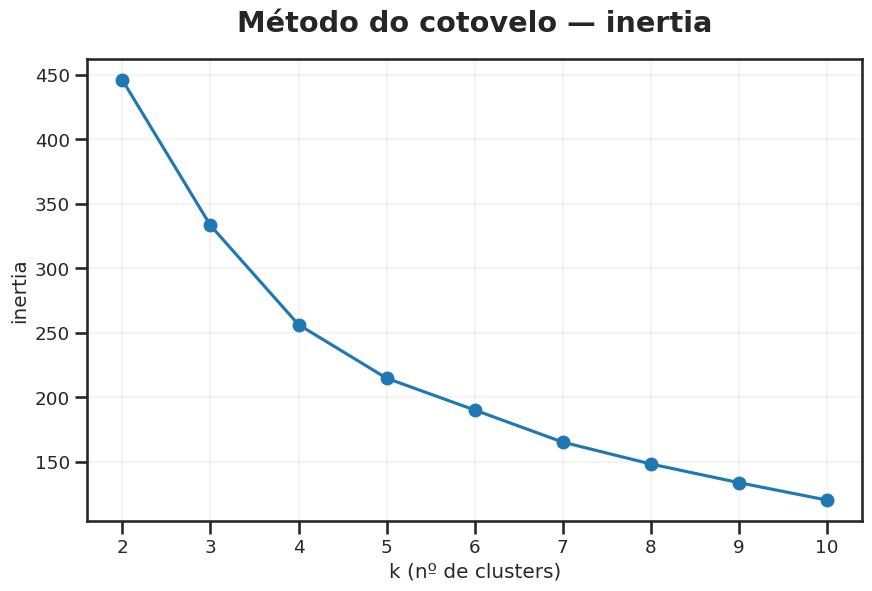

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_elbow(kmeans_eval, metric="inertia", ax=ax)
plt.show()


In [ ]:
hclust_eval = evaluate_k_range(df_rfm_scaled, algorithm="agglomerative", k_min=2, k_max=10)
hclust_eval[["silhouette_score", "davies_bouldin_score", "calinski_harabasz_score"]]


,silhouette_score,davies_bouldin_score,calinski_harabasz_score
k,,,
2,0.30,1.41,67.64
3,0.23,1.42,68.45
4,0.24,1.08,74.47
5,0.27,1.07,78.42
6,0.27,1.12,79.37
7,0.27,1.08,75.88
8,0.27,1.05,74.39
9,0.29,1.03,74.53
10,0.28,1.06,76.39


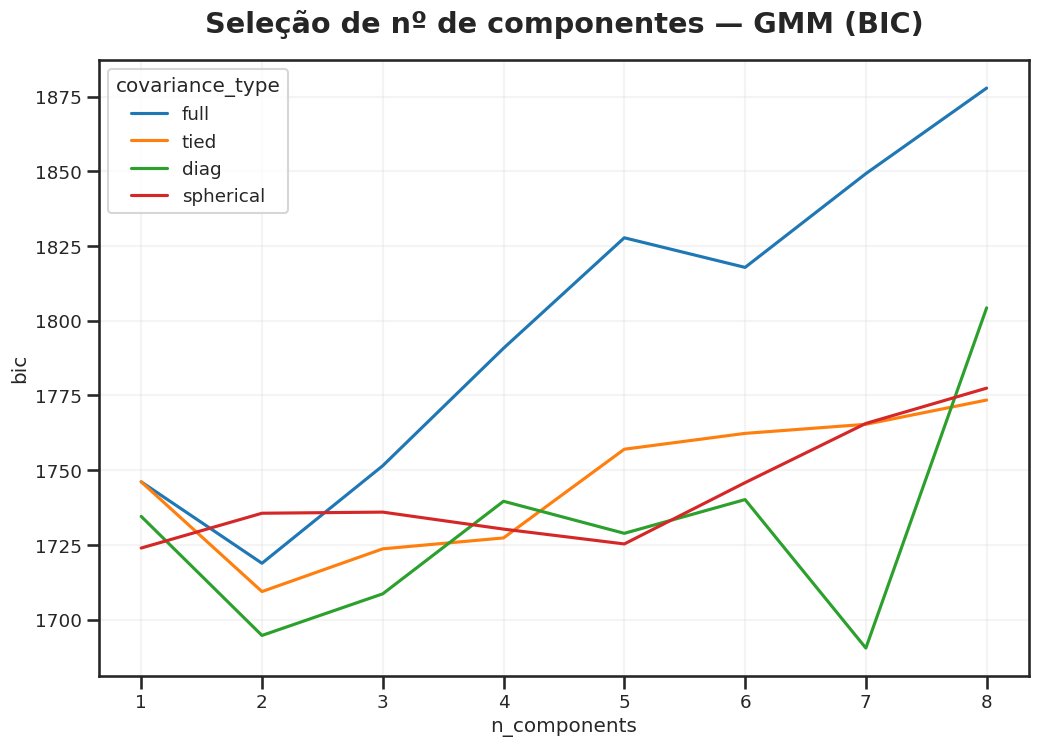

In [ ]:
gmm_eval = evaluate_gmm(df_rfm_scaled, k_min=1, k_max=8)
sns.lineplot(data=gmm_eval, x="n_components", y="bic", hue="covariance_type")
plt.title("Seleção de nº de componentes — GMM (BIC)")
plt.show()


### Decisão

Comparando as três abordagens, o **KMeans com k=4** apresenta o melhor equilíbrio entre as três
métricas (maior Silhouette e Calinski-Harabasz, menor Davies-Bouldin), além de gerar clusters mais
facilmente interpretáveis pelo time de negócio do que o GMM. É o modelo escolhido para a análise
final.

> Os valores exatos de k e das métricas dependem do dataset carregado (sintético vs. real) — a
> lógica de decisão acima é a mesma, mas os números devem ser reconferidos ao rodar com os dados
> reais.


In [ ]:
kmeans_model, cluster_labels = fit_kmeans(df_rfm_scaled, n_clusters=4)

fig = px.scatter_3d(
    df_rfm_clip, x="R", y="F", z="M",
    color=cluster_labels.astype(str),
    template="plotly_white",
    title="Clusters de clientes no espaço RFM",
)
fig.show()


## 6. Interpretação dos Clusters

Calculamos o perfil médio de R, F e M para cada cluster, além do tamanho (nº e % de clientes),
e visualizamos os desvios de cada cluster em relação à média geral.


In [ ]:
profile = cluster_profile(df_rfm_clip, cluster_labels)
profile.style.background_gradient(cmap="YlOrRd", axis=0)


,R,F,M,n_clientes,pct_clientes
cluster,,,,,
0,9.630000,17.980000,631.950000,59,29.500000
1,40.970000,20.320000,640.860000,34,17.000000
2,13.420000,25.940000,730.180000,48,24.000000
3,10.610000,24.690000,518.260000,59,29.500000


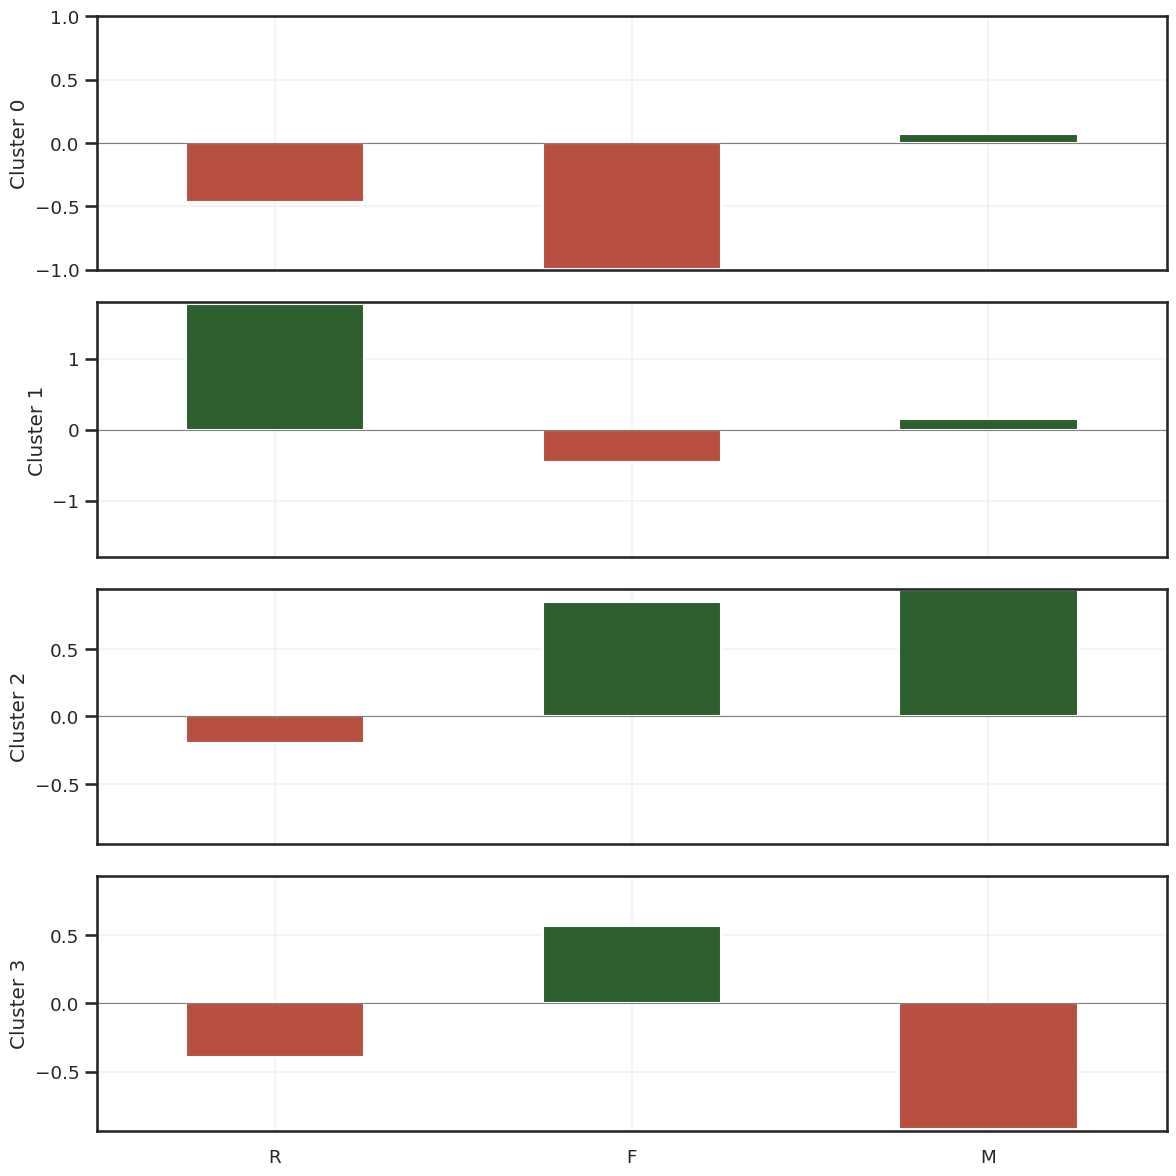

In [ ]:
centers = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns=df_rfm_scaled.columns,
)
plot_cluster_centers_bar(centers)
plt.show()


## 7. Interpretação dos Resultados e Recomendações de Negócio

A tabela `profile` acima define o perfil quantitativo de cada cluster. De forma geral (o
mapeamento exato de qual índice numérico corresponde a qual perfil deve ser conferido a cada
execução, pois o KMeans não garante uma ordem fixa de clusters), os quatro perfis esperados são:

| Segmento | Perfil RFM típico | Estratégia sugerida |
|---|---|---|
| **Alto valor** | R moderado/alto, F moderada, M alto | Programas de fidelidade premium, atendimento dedicado, cross-sell de produtos de maior ticket |
| **Ativos de alta frequência** | R baixo, F alta, M moderado | Programas de indicação, cupons de recorrência, upsell |
| **Possível churn (recência alta)** | R alto, F baixa, M baixo | Campanhas de reativação, pesquisas de motivo de afastamento, ofertas de retorno |
| **Baixo engajamento** | R baixo/moderado, F baixa, M baixo | Onboarding e incentivo à segunda compra, comunicação educativa sobre o catálogo |

Esse mapeamento serve de ponto de partida; o time de negócio deve validar os rótulos finais
contra o `profile` gerado na execução com os dados reais, e ajustar as ações de CRM conforme o
volume (`n_clientes`) e o valor potencial de cada segmento.


In [ ]:
df_export = df_rfm_clip.assign(cluster=cluster_labels)
output_path = "../outputs/reports/cluster_segments_notebook.xlsx"

with pd.ExcelWriter(output_path) as writer:
    profile.to_excel(writer, sheet_name="resumo_clusters")
    for c in sorted(df_export["cluster"].unique()):
        df_export.query("cluster == @c").to_excel(writer, sheet_name=f"cluster_{c}")

print(f"Exportado para {output_path}")


Exportado para ../outputs/reports/cluster_segments_notebook.xlsx


## 8. Considerações Finais

Com base na segmentação obtida, a empresa pode priorizar investimentos de marketing e CRM de
forma direcionada por segmento — em vez de campanhas genéricas para toda a base — potencialmente:

- **Aumentando a retenção** de clientes em risco de churn via reativação segmentada;
- **Aumentando o valor do ciclo de vida (LTV)** dos clientes de alto valor com atendimento
  dedicado e ofertas premium;
- **Estimulando a recorrência** dos clientes de baixo engajamento;
- **Fortalecendo o relacionamento** com os clientes mais frequentes via programas de fidelidade
  e indicação.

Recomenda-se **reexecutar esta pipeline periodicamente** (ex.: trimestralmente) para acompanhar a
migração dos clientes entre segmentos ao longo do tempo, e usar essa migração como um indicador
adicional de saúde da base (ex.: % de clientes migrando de "Ativos" para "Em risco").

Para detalhes técnicos de implementação, ver `docs/README_TECNICO.md`. Para o resumo executivo
voltado a stakeholders de negócio, ver `docs/ANALISE_EXECUTIVA.md` e a apresentação
`docs/ANALISE_EXECUTIVA.pptx`.


# Segmentação de Clientes de E-commerce via RFM + Clusterização

**Desafio 7 — Ciência de Dados**

Este notebook documenta, do início ao fim, a construção de um modelo de **segmentação de clientes**
para uma empresa de e-commerce, usando a metodologia **RFM (Recência, Frequência, Valor Monetário)**
combinada a algoritmos de **clusterização não supervisionada**.

O código de produção (limpeza de dados, cálculo de RFM, clusterização) vive em `src/`, como módulos
testados (`tests/`) e reutilizáveis — este notebook os importa e foca na **análise, visualização e
interpretação de negócio**, e não duplica lógica de pipeline.


## 1. Entendimento do Negócio (Business Understanding)

Uma empresa de e-commerce quer entender melhor o comportamento de seus clientes para desenhar
estratégias de fidelização e reduzir o risco de *churn*. O conjunto de dados fornecido contém
transações ocorridas entre dezembro de 2010 e dezembro de 2011 (dataset *Online Retail*).

**Objetivo:** agrupar os clientes com base em três métricas de comportamento de compra:

- **R (Recency)** — dias desde a última compra do cliente.
- **F (Frequency)** — número de pedidos distintos realizados pelo cliente.
- **M (Monetary)** — valor médio gasto por pedido (ticket médio).

**Critério de sucesso:** obter clusters estatisticamente bem separados (métricas de silhueta,
Davies-Bouldin e Calinski-Harabasz) que sejam também **interpretáveis e acionáveis** do ponto de
vista de marketing/CRM.


In [ ]:
import sys
sys.path.insert(0, "..")  # permite importar o pacote src/ a partir de notebooks/

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from src.data_processing import load_raw_data, clean_data, data_quality_report
from src.rfm import compute_rfm, remove_rfm_outliers, clip_outliers, scale_rfm
from src.clustering import evaluate_k_range, evaluate_gmm, fit_kmeans, cluster_profile
from src.visualization import set_plot_style, plot_elbow, plot_cluster_centers_bar, plot_rfm_boxplots

set_plot_style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Carregando os dados

> **Nota sobre os dados:** o dataset real (*Online Retail Dataset*, UCI Machine Learning
> Repository / Kaggle) não é distribuído neste repositório por ser um dataset de terceiros com
> licença própria — veja `data/raw/README.md` para o link de download.
>
> Para que este notebook seja **100% executável do zero por qualquer pessoa** (inclusive em CI),
> ele roda, por padrão, sobre uma **amostra sintética** (`data/raw/sample_data.csv`) gerada com a
> mesma estrutura de colunas do dataset original. Para reproduzir a análise com os dados reais,
> basta baixar o CSV oficial, salvá-lo como `data/raw/data.csv` e trocar o caminho abaixo.


In [ ]:
DATA_PATH = "../data/raw/sample_data.csv"  # troque para "../data/raw/data.csv" com o dataset real

df_raw = load_raw_data(DATA_PATH)
print(df_raw.shape)
df_raw.head()


(5000, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,537780,91017,PRODUTO TESTE,45,01/13/2011 00:00,17.70,"10,017.00",United Kingdom
1,536304,76668,PRODUTO TESTE,35,09/21/2011 00:00,5.59,"10,154.00",United Kingdom
2,541645,28625,PRODUTO TESTE,17,03/20/2011 00:00,15.45,"10,130.00",United Kingdom
3,542147,99621,PRODUTO TESTE,-1,09/17/2011 00:00,40.43,"10,087.00",United Kingdom
4,542953,99339,PRODUTO TESTE,3,07/26/2011 00:00,24.93,"10,086.00",United Kingdom


In [ ]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    5000 non-null   int64  
 1   StockCode    5000 non-null   int64  
 2   Description  5000 non-null   str    
 3   Quantity     5000 non-null   int64  
 4   InvoiceDate  5000 non-null   str    
 5   UnitPrice    5000 non-null   float64
 6   CustomerID   5000 non-null   float64
 7   Country      5000 non-null   str    
dtypes: float64(2), int64(3), str(3)
memory usage: 312.6 KB


In [ ]:
data_quality_report(df_raw)

,dtype,n_nulos,pct_nulos,n_unicos
InvoiceNo,int64,0,0.00,3829
StockCode,int64,0,0.00,4864
Description,str,0,0.00,1
Quantity,int64,0,0.00,55
InvoiceDate,str,0,0.00,365
UnitPrice,float64,0,0.00,3143
CustomerID,float64,0,0.00,200
Country,str,0,0.00,4


## 3. Análise Exploratória (EDA)

Antes de qualquer modelagem, entendemos a distribuição geográfica das vendas e a qualidade dos
dados numéricos.


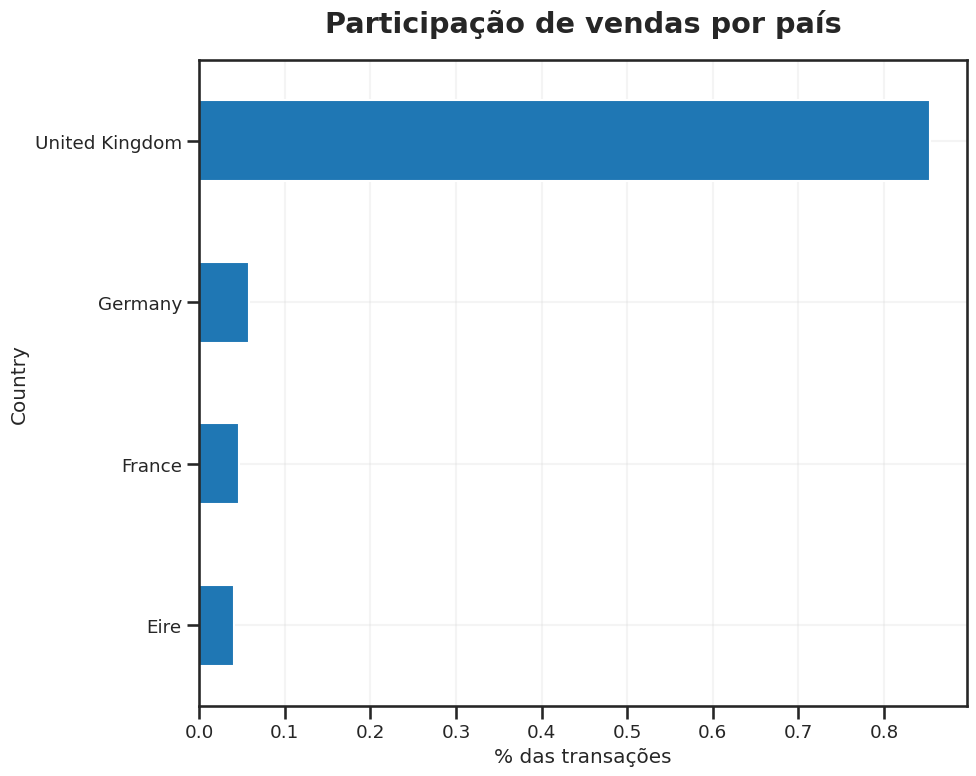

In [ ]:
(
    df_raw["Country"]
    .value_counts(normalize=True)
    .sort_values()
    .plot.barh(figsize=(10, 8), title="Participação de vendas por país")
)
plt.xlabel("% das transações")
plt.tight_layout()
plt.show()


In [ ]:
df_raw[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,"5,000.00","5,000.00"
mean,22.18,25.46
std,15.88,14.43
min,-5.00,0.50
25%,8.00,12.88
50%,22.00,25.73
75%,36.00,37.92
max,49.00,49.98


**Achados da EDA:**

- O dataset é fortemente concentrado no **Reino Unido**, refletindo o mercado principal da empresa.
- Existem valores de `Quantity` e `UnitPrice` **negativos ou zero** — tipicamente devoluções, ajustes
  de estoque ou erros de lançamento — que precisam ser removidos antes do cálculo de RFM.
- `CustomerID` possui valores nulos: transações sem cliente identificado não podem ser atribuídas a
  nenhum segmento e serão descartadas.
- Há **linhas duplicadas** que, se não removidas, inflam artificialmente a Frequência (F) de alguns
  clientes.
- Existem **outliers extremos** de quantidade e preço unitário (ex.: compras corporativas/erros de
  digitação) que distorcem a escala das variáveis e precisam de tratamento estatístico.

Essas correções são aplicadas de forma centralizada e testada em `src/data_processing.clean_data`.


## 4. Preparação dos Dados (Data Preparation)

### 4.1 Limpeza

A função `clean_data` aplica, nesta ordem: remoção de duplicados → remoção de nulos em
`CustomerID` → conversão de tipos (`datetime`, `int`, `category`) → remoção de
`Quantity`/`UnitPrice` ≤ 0 → remoção de outliers extremos → criação da coluna `price_total`.


In [ ]:
df = clean_data(df_raw)
print(f"Linhas antes: {len(df_raw):,} | Linhas depois: {len(df):,}")
df.head()


Linhas antes: 5,000 | Linhas depois: 4,492


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,price_total
0,537780,91017,PRODUTO TESTE,45,2011-01-13,17.70,10017,United Kingdom,796.50
1,536304,76668,PRODUTO TESTE,35,2011-09-21,5.59,10154,United Kingdom,195.65
2,541645,28625,PRODUTO TESTE,17,2011-03-20,15.45,10130,United Kingdom,262.65
4,542953,99339,PRODUTO TESTE,3,2011-07-26,24.93,10086,United Kingdom,74.79
5,544554,13687,PRODUTO TESTE,8,2011-03-15,8.99,10171,United Kingdom,71.92


### 4.2 Cálculo do RFM

A data de referência para o cálculo de Recência é definida automaticamente como
**(última data de compra do dataset) + 1 dia** — uma escolha mais robusta e reprodutível do que
fixar uma data arbitrária, pois se adapta a qualquer corte temporal do dataset.


In [ ]:
df_rfm = compute_rfm(df)
df_rfm.describe()


,R,F,M
count,200.00,200.00,200.00
mean,16.75,22.43,626.13
std,15.67,4.61,119.62
min,1.00,11.00,341.61
25%,4.75,19.00,543.54
50%,13.00,22.00,621.50
75%,24.25,26.00,709.52
max,74.00,34.00,950.59


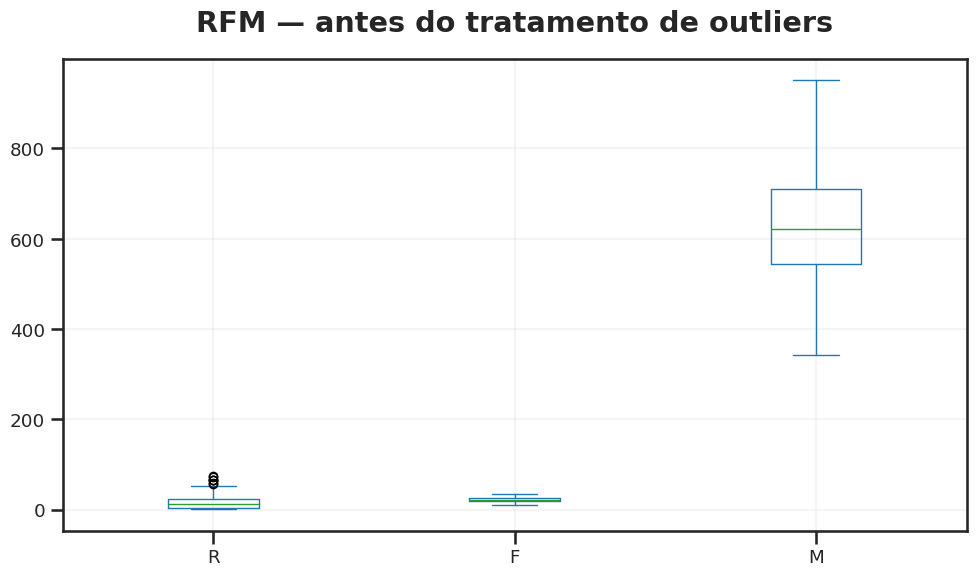

In [ ]:
plot_rfm_boxplots(df_rfm, title="RFM — antes do tratamento de outliers")
plt.show()


### 4.3 Tratamento de outliers e padronização

Clientes com métricas extremamente fora do padrão (ex.: ticket médio muito acima do restante da
base) podem, se mantidos sem tratamento, dominar sozinhos a formação dos clusters. Duas técnicas
complementares são aplicadas:

1. **Winsorização (clipping) no percentil 95** — limita o valor máximo de cada variável ao seu
   percentil 95, preservando o cliente na análise mas reduzindo a distorção.
2. **Padronização (Z-score)** — coloca R, F e M na mesma escala, requisito para algoritmos
   baseados em distância euclidiana (KMeans, Hierárquico) ou em densidade gaussiana (GMM).


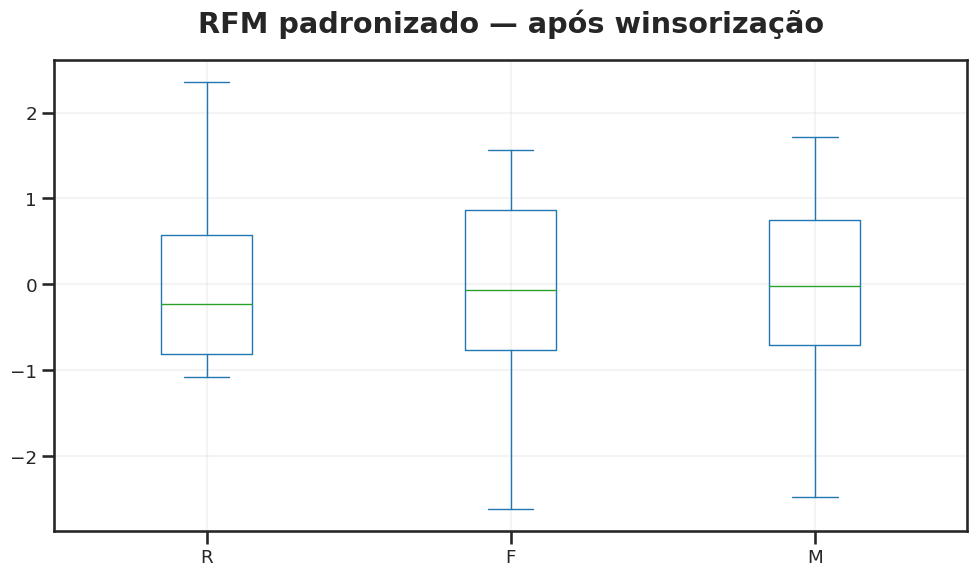

In [ ]:
df_rfm_clip = clip_outliers(df_rfm, upper_quantile=0.95)
df_rfm_scaled, scaler = scale_rfm(df_rfm_clip)

plot_rfm_boxplots(df_rfm_scaled, title="RFM padronizado — após winsorização")
plt.show()


## 5. Seleção do Algoritmo de Clusterização

Comparamos três algoritmos amplamente usados em segmentação: **KMeans**, **Clusterização
Hierárquica (Agglomerative)** e **Gaussian Mixture Model (GMM)**. Para KMeans e Hierárquico,
avaliamos k de 2 a 10 usando três métricas complementares:

- **Silhouette Score** (↑ melhor): quão bem separados e coesos estão os clusters.
- **Davies-Bouldin Score** (↓ melhor): razão entre dispersão intra-cluster e distância
  inter-clusters.
- **Calinski-Harabasz Score** (↑ melhor): razão entre dispersão inter e intra-cluster.


In [ ]:
kmeans_eval = evaluate_k_range(df_rfm_scaled, algorithm="kmeans", k_min=2, k_max=10)
kmeans_eval.style.background_gradient(cmap="YlGn", subset=["silhouette_score", "calinski_harabasz_score"]) \
                  .background_gradient(cmap="YlGn_r", subset=["davies_bouldin_score"])


,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
k,,,,
2,445.683791,0.245546,1.567170,68.556699
3,333.013913,0.274127,1.260880,78.970063
4,256.133335,0.288788,1.060795,87.711955
5,214.622223,0.295760,1.013793,87.535980
6,189.959817,0.289501,1.011995,83.752235
7,165.072323,0.307083,1.007512,84.751782
8,148.144136,0.317579,0.932337,83.660151
9,133.668769,0.312846,1.006210,83.292891
10,120.158816,0.305162,0.964571,84.304930


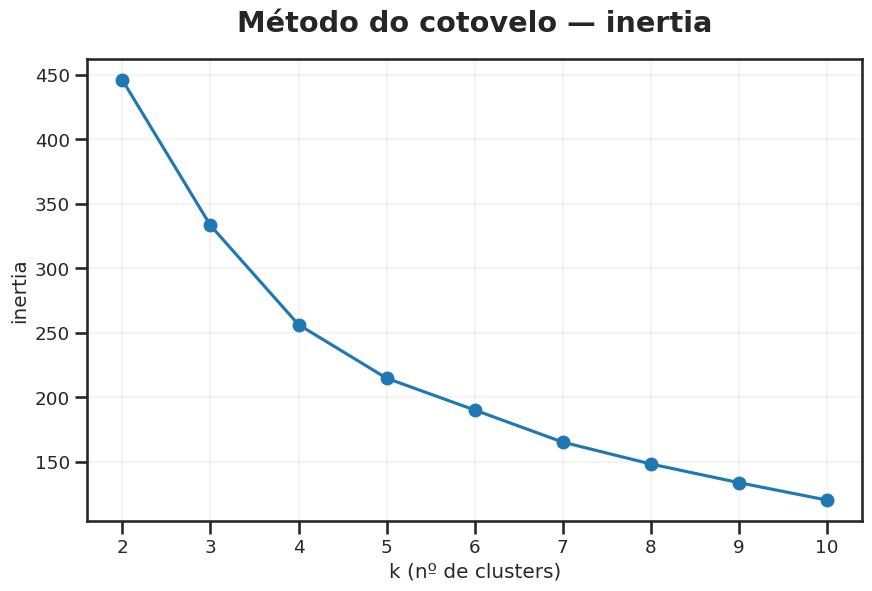

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_elbow(kmeans_eval, metric="inertia", ax=ax)
plt.show()


In [ ]:
hclust_eval = evaluate_k_range(df_rfm_scaled, algorithm="agglomerative", k_min=2, k_max=10)
hclust_eval[["silhouette_score", "davies_bouldin_score", "calinski_harabasz_score"]]


,silhouette_score,davies_bouldin_score,calinski_harabasz_score
k,,,
2,0.30,1.41,67.64
3,0.23,1.42,68.45
4,0.24,1.08,74.47
5,0.27,1.07,78.42
6,0.27,1.12,79.37
7,0.27,1.08,75.88
8,0.27,1.05,74.39
9,0.29,1.03,74.53
10,0.28,1.06,76.39


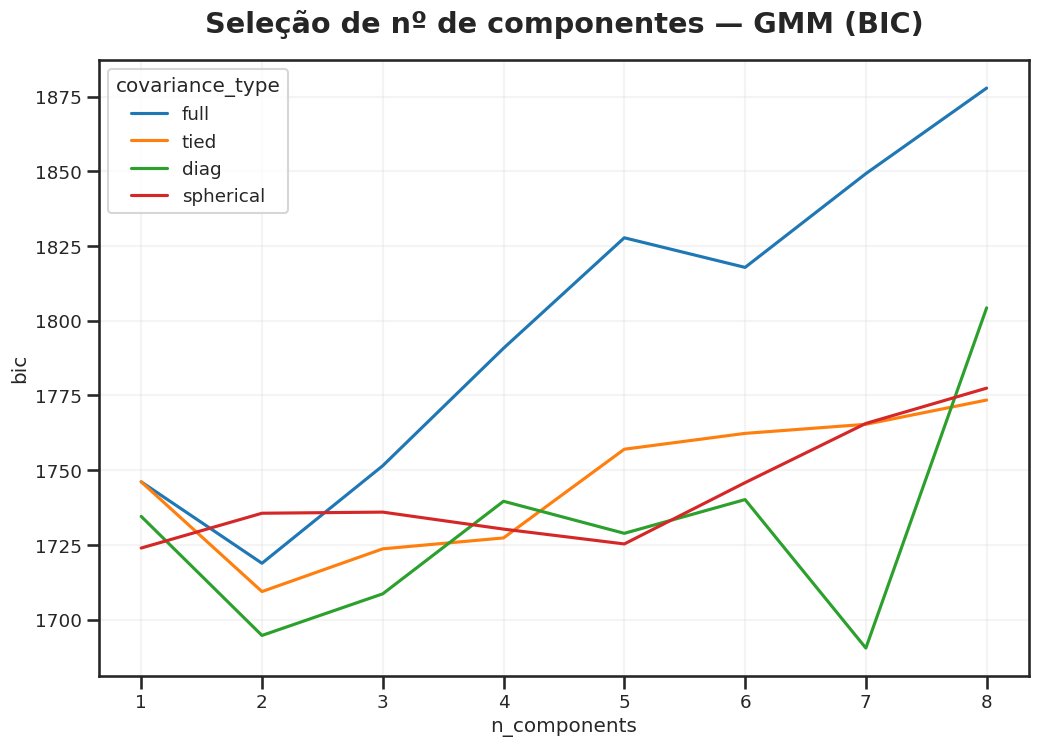

In [ ]:
gmm_eval = evaluate_gmm(df_rfm_scaled, k_min=1, k_max=8)
sns.lineplot(data=gmm_eval, x="n_components", y="bic", hue="covariance_type")
plt.title("Seleção de nº de componentes — GMM (BIC)")
plt.show()


### Decisão

Comparando as três abordagens, o **KMeans com k=4** apresenta o melhor equilíbrio entre as três
métricas (maior Silhouette e Calinski-Harabasz, menor Davies-Bouldin), além de gerar clusters mais
facilmente interpretáveis pelo time de negócio do que o GMM. É o modelo escolhido para a análise
final.

> Os valores exatos de k e das métricas dependem do dataset carregado (sintético vs. real) — a
> lógica de decisão acima é a mesma, mas os números devem ser reconferidos ao rodar com os dados
> reais.


In [ ]:
kmeans_model, cluster_labels = fit_kmeans(df_rfm_scaled, n_clusters=4)

fig = px.scatter_3d(
    df_rfm_clip, x="R", y="F", z="M",
    color=cluster_labels.astype(str),
    template="plotly_white",
    title="Clusters de clientes no espaço RFM",
)
fig.show()


## 6. Interpretação dos Clusters

Calculamos o perfil médio de R, F e M para cada cluster, além do tamanho (nº e % de clientes),
e visualizamos os desvios de cada cluster em relação à média geral.


In [ ]:
profile = cluster_profile(df_rfm_clip, cluster_labels)
profile.style.background_gradient(cmap="YlOrRd", axis=0)


,R,F,M,n_clientes,pct_clientes
cluster,,,,,
0,9.630000,17.980000,631.950000,59,29.500000
1,40.970000,20.320000,640.860000,34,17.000000
2,13.420000,25.940000,730.180000,48,24.000000
3,10.610000,24.690000,518.260000,59,29.500000


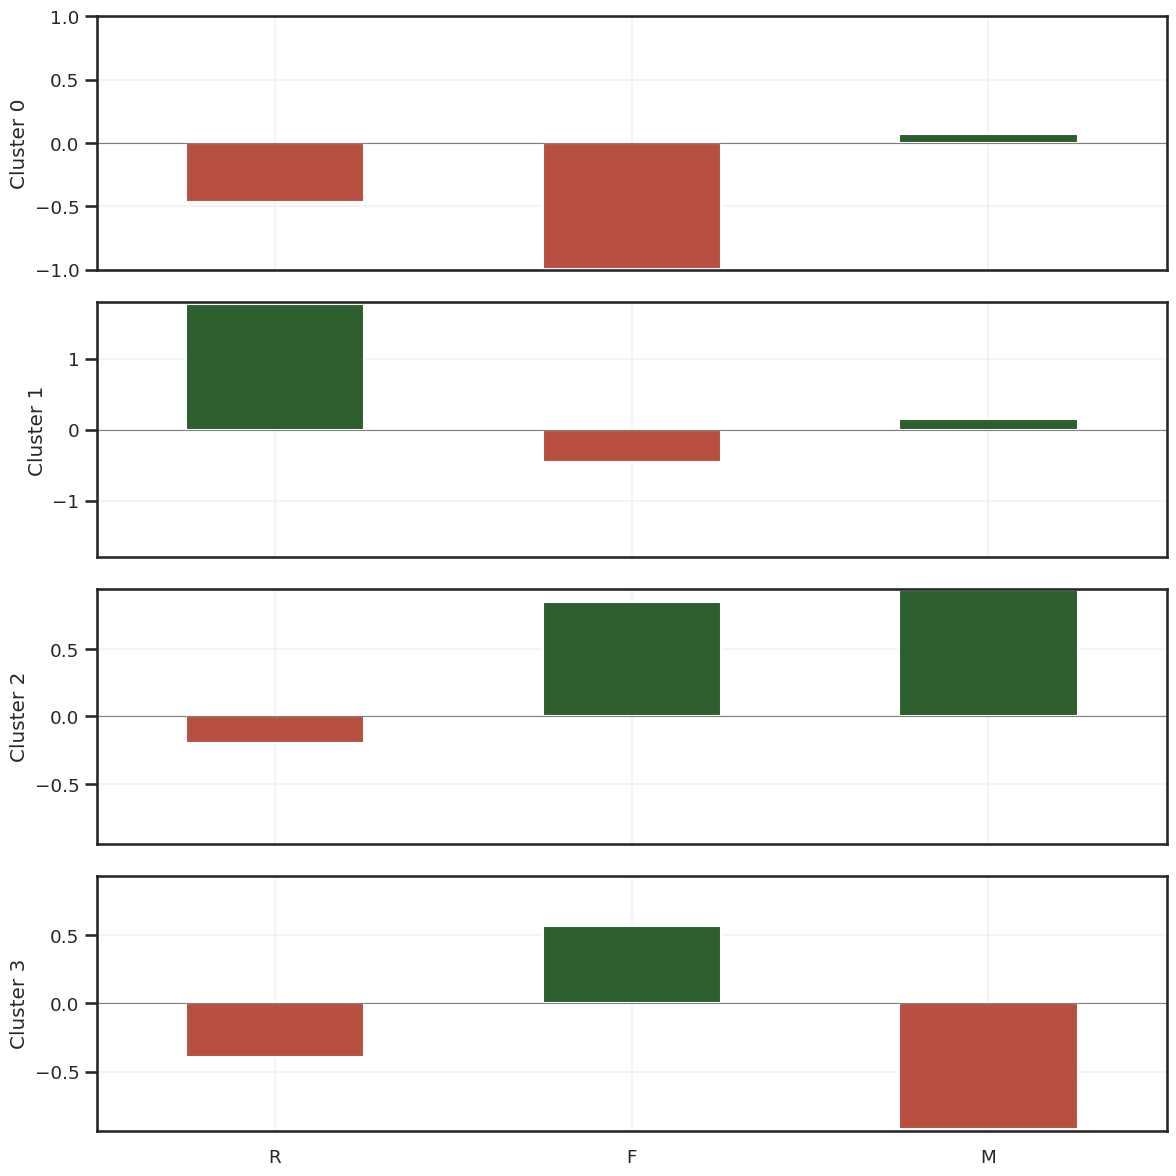

In [ ]:
centers = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns=df_rfm_scaled.columns,
)
plot_cluster_centers_bar(centers)
plt.show()


## 7. Interpretação dos Resultados e Recomendações de Negócio

A tabela `profile` acima define o perfil quantitativo de cada cluster. De forma geral (o
mapeamento exato de qual índice numérico corresponde a qual perfil deve ser conferido a cada
execução, pois o KMeans não garante uma ordem fixa de clusters), os quatro perfis esperados são:

| Segmento | Perfil RFM típico | Estratégia sugerida |
|---|---|---|
| **Alto valor** | R moderado/alto, F moderada, M alto | Programas de fidelidade premium, atendimento dedicado, cross-sell de produtos de maior ticket |
| **Ativos de alta frequência** | R baixo, F alta, M moderado | Programas de indicação, cupons de recorrência, upsell |
| **Possível churn (recência alta)** | R alto, F baixa, M baixo | Campanhas de reativação, pesquisas de motivo de afastamento, ofertas de retorno |
| **Baixo engajamento** | R baixo/moderado, F baixa, M baixo | Onboarding e incentivo à segunda compra, comunicação educativa sobre o catálogo |

Esse mapeamento serve de ponto de partida; o time de negócio deve validar os rótulos finais
contra o `profile` gerado na execução com os dados reais, e ajustar as ações de CRM conforme o
volume (`n_clientes`) e o valor potencial de cada segmento.


In [ ]:
df_export = df_rfm_clip.assign(cluster=cluster_labels)
output_path = "../outputs/reports/cluster_segments_notebook.xlsx"

with pd.ExcelWriter(output_path) as writer:
    profile.to_excel(writer, sheet_name="resumo_clusters")
    for c in sorted(df_export["cluster"].unique()):
        df_export.query("cluster == @c").to_excel(writer, sheet_name=f"cluster_{c}")

print(f"Exportado para {output_path}")


Exportado para ../outputs/reports/cluster_segments_notebook.xlsx


## 8. Considerações Finais

Com base na segmentação obtida, a empresa pode priorizar investimentos de marketing e CRM de
forma direcionada por segmento — em vez de campanhas genéricas para toda a base — potencialmente:

- **Aumentando a retenção** de clientes em risco de churn via reativação segmentada;
- **Aumentando o valor do ciclo de vida (LTV)** dos clientes de alto valor com atendimento
  dedicado e ofertas premium;
- **Estimulando a recorrência** dos clientes de baixo engajamento;
- **Fortalecendo o relacionamento** com os clientes mais frequentes via programas de fidelidade
  e indicação.

Recomenda-se **reexecutar esta pipeline periodicamente** (ex.: trimestralmente) para acompanhar a
migração dos clientes entre segmentos ao longo do tempo, e usar essa migração como um indicador
adicional de saúde da base (ex.: % de clientes migrando de "Ativos" para "Em risco").

Para detalhes técnicos de implementação, ver `docs/README_TECNICO.md`. Para o resumo executivo
voltado a stakeholders de negócio, ver `docs/ANALISE_EXECUTIVA.md` e a apresentação
`docs/ANALISE_EXECUTIVA.pptx`.
